In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("webadvisor/real-time-anomaly-detection-in-cctv-surveillance")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/webadvisor/real-time-anomaly-detection-in-cctv-surveillance


In [2]:
path

'/kaggle/input/datasets/webadvisor/real-time-anomaly-detection-in-cctv-surveillance'

In [3]:
import os
import pandas as pd

root_path = "/kaggle/input/datasets/webadvisor/real-time-anomaly-detection-in-cctv-surveillance/data/"
folder_list = os.listdir(root_path)
label_list = [path for path in folder_list if not path.endswith((".csv"))]

train_df = pd.read_csv(os.path.join(root_path,"train.csv"))
test_df = pd.read_csv(os.path.join(root_path,"test.csv"))

selected_cols = ['label', 'video_name']
train_df = train_df[selected_cols]
test_df = test_df[selected_cols]

total_df = pd.concat([train_df, test_df])
total_df.reset_index(drop = True, inplace = True)
total_df['label'].value_counts()


label
normal           950
roadaccidents    150
robbery          150
stealing         100
burglary         100
explosion         50
fighting          50
vandalism         50
shoplifting       50
arrest            50
assault           50
shooting          50
arson             50
abuse             50
Name: count, dtype: int64

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings as wr
wr.filterwarnings('ignore')


In [5]:

df = pd.read_csv("/kaggle/input/datasets/webadvisor/real-time-anomaly-detection-in-cctv-surveillance/data/train.csv",index_col=0)

df.describe()
df.isnull().sum()
df['label']

1229           normal
551            normal
715            normal
1366    roadaccidents
501            normal
            ...      
1359    roadaccidents
1169           normal
784            normal
1088           normal
439            normal
Name: label, Length: 1520, dtype: object

In [6]:
import pandas as pd
df = pd.read_csv("/kaggle/input/datasets/webadvisor/real-time-anomaly-detection-in-cctv-surveillance/data/train.csv")
print(df.shape)
print(df.dtypes)
print(df.head(10))
print(df.describe())
print(df.isnull().sum())

(1520, 3)
Unnamed: 0     int64
label         object
video_name    object
dtype: object
   Unnamed: 0          label                                    video_name
0        1229         normal        data\normal\Normal_Videos_196_x264.mp4
1         551         normal         data\normal\Normal_Videos179_x264.mp4
2         715         normal         data\normal\Normal_Videos361_x264.mp4
3        1366  roadaccidents  data\roadaccidents\RoadAccidents017_x264.mp4
4         501         normal         data\normal\Normal_Videos125_x264.mp4
5         534         normal         data\normal\Normal_Videos160_x264.mp4
6         704         normal         data\normal\Normal_Videos348_x264.mp4
7         818         normal         data\normal\Normal_Videos470_x264.mp4
8         449         normal         data\normal\Normal_Videos072_x264.mp4
9        1415  roadaccidents  data\roadaccidents\RoadAccidents067_x264.mp4
        Unnamed: 0
count  1520.000000
mean    950.773026
std     549.258852
min       0.

Text(0.5, 1.0, 'Event Class Distribution')

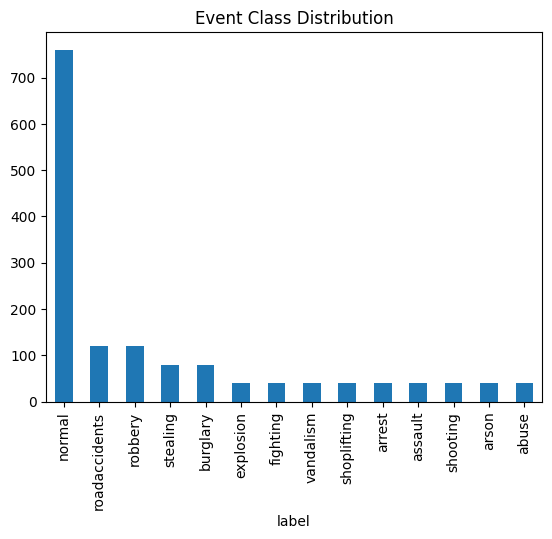

In [7]:
import matplotlib.pyplot as plt
df['label'].value_counts().plot(kind='bar')
plt.title("Event Class Distribution")

In [8]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/webadvisor/real-time-anomaly-detection-in-cctv-surveillance/data/train.csv")  # or your dataframe already

# remove useless column
df = df.drop(columns=["Unnamed: 0"])
df = df.reset_index(drop=True)

In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])

In [10]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['label'],
    random_state=42
)

In [11]:
df = train_df.groupby('label').apply(
    lambda x: x.sample(30, replace=True)
).reset_index(drop=True)

In [12]:
print(df['label'].value_counts())

label
abuse            30
arrest           30
arson            30
assault          30
burglary         30
explosion        30
fighting         30
normal           30
roadaccidents    30
robbery          30
shooting         30
shoplifting      30
stealing         30
vandalism        30
Name: count, dtype: int64


In [13]:
pip install numpy pandas matplotlib keras scikit-image opencv-python


Note: you may need to restart the kernel to use updated packages.


In [14]:
import cv2     # for capturing videos
import math   # for mathematical operations
import matplotlib.pyplot as plt    # for plotting the images
%matplotlib inline
import pandas as pd
from keras.preprocessing import image   # for preprocessing the images
import numpy as np    # for mathematical operations
from keras.utils import to_categorical
from skimage.transform import resize   # for resizing images

2026-04-15 11:34:15.779320: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776252855.967135      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776252856.029740      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776252856.511048      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776252856.511087      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776252856.511090      23 computation_placer.cc:177] computation placer alr

In [15]:
import cv2
vid = cv2.VideoCapture("/kaggle/input/datasets/webadvisor/real-time-anomaly-detection-in-cctv-surveillance/data/explosion/Explosion003_x264.mp4")

count, success = 0, True
while success:
    success, image = vid.read() # Read frame
    if success: 
        cv2.imwrite(f"frame{count}.jpg", image) # Save frame
        count += 1

vid.release()